# Phase Hyperparameters:

Considered Hyperparameters:
- Macro-structure:
  - Layers
  - Neurons
  - Multiplicity
- Micro-structure:
  - Grid
  - Order
  - Initial Function (function, noise scale, seed)
- Training:
  - Solver
  - Learning rate
  - Epochs
  - Pruning
  - Refinement

## [0]

In [ ]:
# --- Imports
import torch
torch.set_default_dtype(torch.float64)
for i in range(torch.cuda.device_count()):
    print(f'Device: {torch.cuda.get_device_properties(i).name}')
if torch.cuda.is_available():
    i = 0
    torch.cuda.set_device(i)
    device = f'cuda:{i}'
    torch.set_default_device(f'cuda:{i}')
    print(f"Cuda is available. Setting default device to: {torch.cuda.get_device_properties(i).name}")
else:
    print('Cuda is not available. Setting default device to: CPU')
    device = 'cpu'

import kan
import matplotlib.pyplot as plt
import numpy as np
import scipy
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import time as timing

Device: NVIDIA GeForce RTX 4060 Laptop GPU
Cuda is available. Setting default device to: NVIDIA GeForce RTX 4060 Laptop GPU


In [ ]:
# --- Model Wrapper
class KanModel:
# Initialize model
    def __init__(
                 self,
                 dataset,
                 hidden_layers,
                 device,
                 **kwargs
                 ):
        n_inputs = dataset['train_input'].shape[1]
        n_outpts = dataset['train_label'].shape[1]
        width = [n_inputs] + hidden_layers + [n_outpts]

        self.model = kan.KAN(width=width, device=device, **kwargs)
        self.dataset = dataset
        self.history = {"train":[],"tests":[]}
        self.device = device
        return
# Train model
    def fit(
            self,
            dataset = None,
            **kwargs
           ):
        dataset = dataset if dataset else self.dataset
        results = self.model.fit(dataset, **kwargs)
        self.history['train'] += results['train_loss']
        self.history['tests'] += results['test_loss']
        return results
# Prune model
    def prune(
              self,
              node_th = None,
              edge_th = None,
              input_th = None,
              **kwargs
             ):
        if node_th:
            try:
                self.model = self.model.prune_node(node_th, **kwargs)
            except:
                print("Node pruning failed.")
        if edge_th:
            try:
                self.model.prune_edge(edge_th)
            except:
                print('Edge pruning failed.')
        if input_th:
            try:
                self.model = self.model.prune_input(input_th)
            except:
                print('Input pruning failed.')
        return
# Refine model
    def refine(
               self,
               num = 0,
               factor = 1,
               **kwargs,
              ):
        new_grid = num if num else self.model.grid * factor 
        #print(new_grid)
        self.model = self.model.refine(new_grid)
        #print(self.model.grid)
        return
# Plot model training
    def plot_training(
                      self,
                      **kwargs
                     ):
        fig, axs = plt.subplots(1,1)
        axs.plot([i for i in range(len(self.history["train"]))], self.history["train"], label='Training')
        axs.plot([i for i in range(len(self.history["tests"]))], self.history["tests"], label='Testing')
        axs.set_yscale('log'); axs.set_ylabel('Loss');axs.set_xlabel("Steps"); axs.grid(visible=True, which='both'); axs.legend(loc='upper right')
        fig.tight_layout()
        return fig
# Plot model performance
    def plot_performance(
                         self,
                         dataset = None,
                         **kwargs
                        ):
        
        Y_TRUE = dataset['test_label'] if dataset else self.dataset['test_label']
        Y_PREDICTED = self.model(dataset['test_input']) if dataset else self.model(self.dataset['test_input'])

        Y_TRUE = Y_TRUE.detach().cpu().numpy()
        Y_PREDICTED = Y_PREDICTED.detach().cpu().numpy()

        fig, axs = plt.subplots(1,2, figsize=(12,4))

        ax=axs[0]
        ax.scatter(Y_TRUE, Y_PREDICTED, alpha=0.25, label=f"Model")
        ax.plot(np.linspace(np.min(Y_TRUE), np.max(Y_TRUE),100),np.linspace(np.min(Y_TRUE), np.max(Y_TRUE),100), color='black',ls='--', label="True")
        ax.set_xlabel("f(x)"); ax.set_ylabel("KAN(x)"); ax.legend(); ax.grid(visible=True, color='gainsboro')

        ax=axs[1]
        residuals = Y_PREDICTED[:,0] - Y_TRUE[:,0]
        pdf_fit = scipy.stats.norm.fit(residuals)
        pdf_pdf = scipy.stats.norm.pdf(np.linspace(-0.3,0.3,100), *pdf_fit)
        ax.hist(residuals, bins=100, color='cornflowerblue', density=True)
        ax.plot(np.linspace(-0.3,0.3,100), pdf_pdf, label=f'Fit: {[round(i,3) for i in pdf_fit]}')
        ax.set_xlabel("Residual"); ax.set_ylabel("Relative Frequency"); ax.grid(visible=True, color='gainsboro', label='Raw Data'); ax.legend()

        fig.tight_layout()
        return
# Evaluate model performance
    def evaluate_performance(
                            self,
                            dataset = None,
                            **kwargs,
                            ):
        nx = dataset['test_input'].shape[1] if dataset else self.dataset['test_input'].shape[1]
        Y_TRUE = dataset['test_label'] if dataset else self.dataset['test_label'].detach().cpu().numpy()
        n = Y_TRUE.shape[0]
        Y_PREDICTED = self.model(dataset['test_input']).detach().cpu().numpy() if dataset else self.model(self.dataset['test_input']).detach().cpu().numpy()
        r2 = r2_score(Y_TRUE, Y_PREDICTED)
        mae = mean_absolute_error(Y_TRUE, Y_PREDICTED)
        mse = mean_squared_error(Y_TRUE, Y_PREDICTED)
        adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-nx-1))
        rmse = np.sqrt(mse)
        maxerr = np.max(Y_PREDICTED/Y_TRUE - 1)
        print(f"R2: {r2}\tMAE: {mae}\tMSE: {mse}\tAdjR2 {adjusted_r2}\tRMSE: {rmse}\tMaxAE: {maxerr}")
        return {'R2':r2, 'MAE':mae, 'MSE':mse, 'adjR2':adjusted_r2, 'RMSE':rmse, 'MaxAE':maxerr}
# Plot model
    def plot(
             self,
             **kwargs
            ):
        self.model.plot(**kwargs)
        return
# Fix and obtain symbolic functions
    def symbolize(
                  self,
                  library = None,
                  **kwargs
                  ):
        self.model.auto_symbolic(library)
        return kan.utils.ex_round(self.model.symbolic_formula()[0][0],4) # type:ignore

In [4]:
# --- Alternative Generator
def generate_dataset(
                     function,
                     n_ins,
                     n_out,
                     train_num = 1000,
                     tests_num = 1000,
                     ranges = [[-1,1]],
                     device = 'cpu',
                     random_state = 43,
                     generator = scipy.stats.uniform,
                     **kwargs
                     ):
    if len(ranges) == 1:
        ranges = [ranges[0] for i in range(n_ins)]
    # Templates
    train_inputs = torch.zeros((train_num, n_ins))
    tests_inputs = torch.zeros((tests_num, n_ins))
    # Sample from inputs
    for i in range(n_ins):
        train_inputs[:,i] = torch.tensor(generator.rvs(ranges[i][0], ranges[i][1]-ranges[i][0], train_num, random_state=random_state+i))
    for i in range(n_ins):
        tests_inputs[:,i] = torch.tensor(generator.rvs(ranges[i][0], ranges[i][1]-ranges[i][0], tests_num, random_state=random_state+n_ins+i))
    # Compute outputs
    train_output = function(train_inputs)
    tests_output = function(tests_inputs)

    # Compute means and stds
    train_inputs_mu = torch.mean(train_inputs,0)
    train_inputs_sd = torch.std(train_inputs,0)
    tests_inputs_mu = torch.mean(tests_inputs,0)
    tests_inputs_sd = torch.std(tests_inputs,0)

    train_output_mu = torch.mean(train_output,0)
    train_output_sd = torch.std(train_output,0)
    tests_output_mu = torch.mean(tests_output,0)
    tests_output_sd = torch.std(tests_output,0)
    # Normalize
    train_inputs = (train_inputs - train_inputs_mu)/train_inputs_sd
    tests_inputs = (tests_inputs - tests_inputs_mu)/tests_inputs_sd
    train_output = (train_output - train_output_mu)/train_output_sd
    tests_output = (tests_output - tests_output_mu)/tests_output_sd
    # Package
    return_dict = {
                   'train_input':train_inputs.to(device),
                   'test_input':tests_inputs.to(device),
                   'train_label':train_output.to(device),
                   'test_label':tests_output.to(device)
                   }
    stats_dict = {
                  'train_input':(train_inputs_mu.to(device), train_inputs_sd.to(device)),
                  'test_input':(tests_inputs_mu.to(device), tests_inputs_sd.to(device)),
                  'train_label':(train_output_mu.to(device), train_output_sd.to(device)),
                  'test_label':(tests_output_mu.to(device), tests_output_sd.to(device)),
                  }
    return return_dict, stats_dict


## [1]

In [8]:
f = lambda x: torch.tanh(5*(x[:,[0]]**4 + x[:,[1]]**4 + x[:,[2]]**4 - 1))
dataset, statistics = generate_dataset(f, 3, 1, 20000, 2000, ranges=[[-1.2,1.2]], device='cuda:0')
print(dataset['test_input'].shape)
print(dataset['test_label'].shape)

torch.Size([2000, 3])
torch.Size([2000, 1])


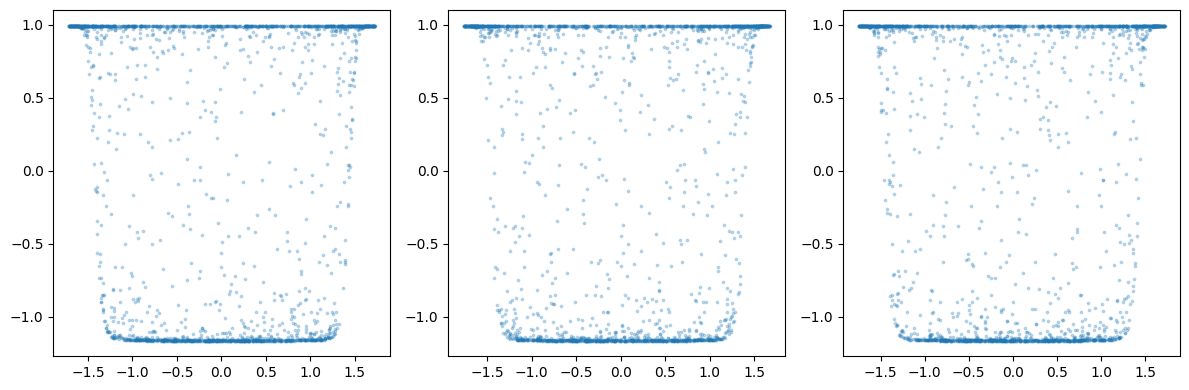

In [12]:
fig, axs = plt.subplots(1,3, figsize=(12,4))

ax=axs[0]
ax.scatter(dataset['test_input'][:,0].cpu(), dataset['test_label'][:,0].cpu(), s=3, alpha=0.25)

ax=axs[1]
ax.scatter(dataset['test_input'][:,1].cpu(), dataset['test_label'][:,0].cpu(), s=3, alpha=0.25)

ax=axs[2]
ax.scatter(dataset['test_input'][:,2].cpu(), dataset['test_label'][:,0].cpu(), s=3, alpha=0.25)

fig.tight_layout()

## [2]

### [2.1] Layers and Neurons

Consistent initialization function, grid, order, solver, learning rate, epochs, and no pruning/refinement.

In [ ]:
def evaluate_hyprm(
                   single_param: dict,
                   construction_args: dict,
                   training_args: dict,
                   dataset: dict
                   ):
    
    timer0 = timing.time()
    quickmodel = KanModel(dataset, **single_param, **construction_args, device=device)
    quickmodel.fit(dataset, **training_args)
    metrics = quickmodel.evaluate_performance(dataset)
    timer1 = timing.time()
    metrics['runtime'] = timer1 - timer0

    return metrics